In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

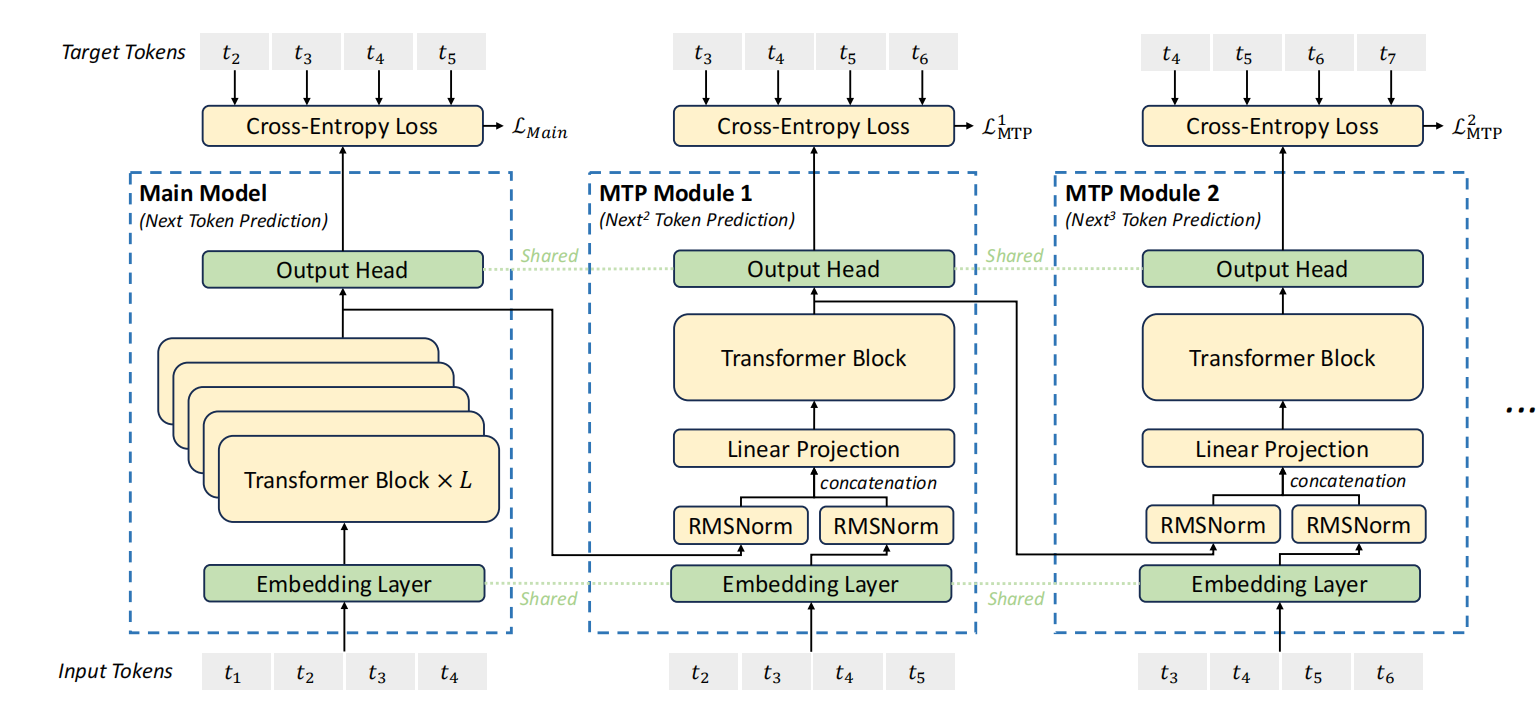

In [3]:
from IPython.display import Image, display
# Windows 示例: 'C:/Users/你的用户名/Desktop/MLA-Prefill.png'
# macOS/Linux 示例: '/Users/你的用户名/Desktop/MLA-Prefill.png'
image_path = r'C:/Users/1/Desktop/MTP.png'  # ← 修改这里！

display(Image(filename=image_path))

# 替换为你的桌面

# RMSNorm的实现

In [7]:
class RMSNorm(nn.Module):
    def __init__(self,d_model,eps=1e-8):
        super().__init__()
        self.eps = eps

        #可学习的缩放参数
        self.scale = nn.Parameter(torch.ones(d_model))
    def forward(self,x):
        """ x' = x / (rms + eps) * scale
        """
        rms = torch.sqrt(torch.mean(x ** 2, dim=-1, keepdim=True))

        # 归一化并缩放
        return x / (rms + self.eps) * self.scale

# MTP 主体的核心实现

In [8]:
class MultiTokenPredictionHead(nn.Module):
    '''MTP 输出头的代码'''
    def __init__(self,d_model,nhead,dropout=0.1):
        super().__init__()
        # 结合 previous hidden state 和 current token embedding 做线性映射
        self.combine_proj = nn.Linear(2 * d_model, d_model, bias=False)
        # 归一化层 做俩次归一化
        self.prev_norm = RMSNorm(d_model)
        self.cur_norm = RMSNorm(d_model)
        # Transformer层
        self.mtp = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout)

    def forward(self,prev_hidden, cur_token_embed):
        # prev_hidden shape: [Batch, seq_len, d_model]
        # cur_token_embed shape: [Batch, seq_len, d_model]
        # 归一化输入
        prev_norm = self.prev_norm(prev_hidden)
        cur_norm = self.cur_norm(cur_token_embed)

        # concat 和线性映射
        combined = torch.cat([prev_norm, cur_norm], dim=-1)
        hidden = self.combine_proj(combined)

        # MTP 头的transformer编码
        hidden = hidden + self.mtp(hidden)

        return hidden

# 手写 MTP 多 TOKEN 预测

In [17]:
class MTP(nn.Module):
    '''MTP forward + loss 的核心实现
    '''

    def __init__(self,d_model,vocab_size,mtp_heads=3,nheads=2,dropout=0.1,num_layers=3):
        """
           Args:
               d_model: 隐藏层的维度
               vocab_size: 词汇表大小
               mtp_heads: MTP头的个数
               nhead: transformer block的头数(多头注意力)
               num_layers: transformer block的层数
        """
        super().__init__()

        self.d_model = d_model
        self.vocab_size = vocab_size
        self.mtp_heads = mtp_heads

        #公共模块 Embedding Layer层 ， RMSNorm层， Output Head层
        self.rmsnorm = RMSNorm(d_model)
        self.embed = nn.Embedding(vocab_size, d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        # 如果 embedding 层要和输出层共享
        #self.lm_head.weight = self.embed.weight

        #主编码器，创建一个Transformer的编码器
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nheads, dropout=dropout)
        self.backbone = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        #MTP 主体的定义
        self.mtp_heads =nn.ModuleList([MultiTokenPredictionHead(d_model, nheads, dropout) for _ in range(mtp_heads)])

    def forward(self,token_ids,targets, mtp_loss_weight=0.3):
        """
            token ids: [batch, seq_len]
            targets: [batch, seq_len]
            这里还没有 embedding
        """
        batch_size,seq_len = token_ids.shape
        d_model = self.d_model

        #第一步 先做词嵌入，总的词嵌入向量
        # [batch, seq_len，d_model]
        embeds = self.embed(token_ids)

        #第二步，将embeds在主体模型 main model 中进行编码，[batch, seq_len，d_model]不改变形状
        h0_seq = self.backbone(embeds)

        # 3.计算 main model 的 logits 和 loss
        main_logits = self.lm_head(h0_seq) # [batch, seq_len, vocab]
        main_loss = F.cross_entropy(
            main_logits.view(-1,main_logits.size(-1)),
            targets.view(-1),
            ignore_index=-100
        )

        # MTP head 的 logits 和 loss 计算,从1开始
        mtp_losses = []
        current_hidden = h0_seq
        for depth, mtp_head in enumerate(self.mtp_heads, 1):
            """
            main head input ids: 1,2,3,4,5
            target input ids: 2,3,4,5,-100
            mtp head input ids: 2,3,4,5|3,4,5|4,5
            """

            # 获取当前depth所需的词向量长度
            # current token embedding，[batch, seq_len-depth, d_model]
            future_embeds = embeds[:, depth:, :]

            # 右移后的长度不够的补0，假设pad_token=0
            pad_size = embeds.size(1)-future_embeds.size(1)
            padding = torch.zeros(batch_size,pad_size,d_model)
            # padding 后的 shape = [batch, seq_len, d_model]
            future_embeds = torch.cat([future_embeds, padding], dim=1)

            #当前的头 过一遍 MTP 模块 mtp_head就是当前正在遍历的transformer流程
            # 第二次就把current_hidden变换了
            current_hidden = mtp_head(current_hidden, future_embeds)

            #计算当前的 MTP head 的logits
            mtp_logits = self.lm_head(current_hidden) # [batch, seq_len, vocab]

            #计算logits , 一般 eos = pad =0
            # 比如第一个头，输入是: [2,3,4,5,0], 预测的token是: [3,4,5,0,0], targets: [2,3,4,5,-100]
            #拿出需要计算的logits
            shift_logits = mtp_logits[:, :-depth, :].contiguous() # [batch,  seq_len - depth, vocab]
            shift_targets = targets[:, depth:].contiguous() # [batch,  seq_len - depth] 要取 3,4,5,-100，不要2

             # 第一个头真正参与计算的tokens
            # input: [2,3,4]
            # targets: [3,4,5]
            mtp_head_loss = F.cross_entropy(
                shift_logits.view(-1, shift_logits.size(-1)),
                shift_targets.view(-1),
                ignore_index=-100 # 忽略 -100的label，不计算loss
            )
            # 补充mtp_losses
            mtp_losses.append(mtp_head_loss)

        # MTP loss求平均
        mtp_loss = torch.stack(mtp_losses).mean()

        # Combine loss，结合权重
        # mtp_loss_weight 是一个权重 (0.3->0.1)
        total_loss = main_loss + mtp_loss_weight * mtp_loss
        return main_logits, total_loss, main_loss, mtp_loss, mtp_losses

In [18]:
torch.random.manual_seed(42)

# 超参数
batch_size = 8
seq_len = 5
d_model = 128
mtp_heads = 3
vocab_size = 5000

# 构造输入
PAD = 0
IGNORE_INDEX = -100
tokens = torch.randint(1, vocab_size, (batch_size, seq_len))
pad_tokens = IGNORE_INDEX + torch.zeros(batch_size, 1).type_as(tokens)
targets = torch.cat([tokens[:, 1:], pad_tokens], dim=-1)
print("inputs: ", tokens)
print("targets: ", targets)

# 实例化一个模型
model = MTP(d_model, vocab_size, mtp_heads)

# 过一次 forward
main_logits, total_loss, main_loss, mtp_loss, mtp_losses = model(tokens, targets)

# 打印 loss
print("inputs shape: ", tokens.shape)
print("main logits shape: ", main_logits.shape)
print("main loss: ", main_loss.item())
for idx, hl in enumerate(mtp_losses):
    print(f"head {idx} loss: ", hl.item())
print("mtp average loss: ", mtp_loss.item())
print("total loss: ", total_loss.item())

inputs:  tensor([[4334,  430, 3697, 4015, 3930],
        [2219, 2967, 4717, 3996,  158],
        [ 404, 4909, 2114, 3525, 2420],
        [4283,  773, 1042, 1919, 3927],
        [2435, 4343, 4386, 1428, 4105],
        [4585, 1976,  439, 3505, 3693],
        [3947, 3399, 1870,  841, 2586],
        [ 636,  852, 2191, 4846,  879]])
targets:  tensor([[ 430, 3697, 4015, 3930, -100],
        [2967, 4717, 3996,  158, -100],
        [4909, 2114, 3525, 2420, -100],
        [ 773, 1042, 1919, 3927, -100],
        [4343, 4386, 1428, 4105, -100],
        [1976,  439, 3505, 3693, -100],
        [3399, 1870,  841, 2586, -100],
        [ 852, 2191, 4846,  879, -100]])
inputs shape:  torch.Size([8, 5])
main logits shape:  torch.Size([8, 5, 5000])
main loss:  8.530102729797363
head 0 loss:  8.968270301818848
head 1 loss:  8.942724227905273
head 2 loss:  9.29455280303955
mtp average loss:  9.06851577758789
total loss:  11.25065803527832
